# H2 — Misallocation: the current MBSP backlog is not population-targeted

**Claim under test.** The Mobile Black Spot Program's still-unbuilt NT sites show no sign of being
placed to reach at-risk population, while a reproducible, population-weighted method using the same
number of sites clearly does.

Two one-sided Monte Carlo tests against the same null (a random choice of 8 sites from the fragile
candidate pool):

- **Test A -- does MBSP show population targeting?**
  H0: MBSP-unbuilt reaches no more population than a random 8-site choice.
  H1: it reaches more (i.e. it is population-targeted).
- **Test B -- is population targeting achievable here at all?**
  Same H0/H1, for the greedy population-weighted selection.

**H2 is supported** when Test A finds *no evidence* of targeting (p >= 0.05) **and** Test B does
(p < 0.05). Read Test A carefully: failing to reject H0 means MBSP's reach is *indistinguishable from
random* -- it is absence of evidence of targeting, not proof that MBSP is worse than chance.

**Data:** `village_gap_with_services.csv` + `sa1_report.csv` (population, `notebooks/02`) +
`program_sites.csv` (MBSP sites, `notebooks/05`).

**Population rule.** Demand is the 2021 Census count, **once per SA1**, never split across the villages
inside it and never taken from BushTel. BushTel villages are reference points only: they locate the
SA1's demand and are the candidate sites. A sensitivity check drops SA1s that also contain a
well-covered village, where part of the SA1's population may already be served.

**Method: Monte Carlo permutation test.** There is no closed-form sampling distribution for
"population reached by k randomly chosen sites under a spatial union-coverage function", so we
build the null distribution empirically: draw 10,000 random 8-site subsets from the same
candidate pool, compute population reached by each, and locate both the MBSP-unbuilt and the
greedy statistics against that empirical distribution. See
`hypothesis_proof_notebooks/greedy_algorithm_explained.txt` for how the greedy method itself
works, with a fully worked hand-checkable numeric example.


In [1]:
# Every import for the whole notebook lives in this cell.
%matplotlib inline
import os
from pathlib import Path

if os.path.basename(os.getcwd()) == "hypothesis_proof_notebooks":
    os.chdir("..")

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 220)
DATA = Path("data/processed")


In [2]:
vg = pd.read_csv(DATA / "village_gap_with_services.csv", dtype={"sa1_code": str})
sa1 = pd.read_csv(DATA / "sa1_report.csv", dtype={"sa1_code": str})[["sa1_code", "pop_census_2021"]]
prog = pd.read_csv(DATA / "program_sites.csv")
vg = vg.merge(sa1, on="sa1_code", how="left")

def classify(row) -> str:
    if row["distance_gap_candidate"] == True:
        return "beyond"
    if row["n_towers_10km"] == 0:
        return "spof"
    if row["n_networks_10km"] <= 1:
        return "single_net"
    return "redundant"

vg["resilience_tier"] = vg.apply(classify, axis=1)
fragile = vg[vg["resilience_tier"].isin(["beyond", "spof", "single_net"])].reset_index(drop=True)
print(f"fragile communities (candidate pool): {len(fragile)} of {len(vg)}")

fragile communities (candidate pool): 691 of 792


## The demand surface and the candidate pool

Demand = 2021 Census population, counted **once per SA1** (never split across the villages
inside it — the project's own population rule, `docs/PROJECT_CONTEXT.md` §2), restricted to
the SA1s that contain a fragile community. Candidate sites = the fragile communities
themselves (a hub has to be a real place).

Where the SA1's people are inside it is unknown (no village-level population), so each SA1's demand
point is the mean position of its fragile villages, and an SA1 counts as reached when that point is
within the radius. This is triage-level geography, consistent with the rest of the project.

In [3]:
sa1_demand = (fragile.groupby("sa1_code")
              .agg(pop=("pop_census_2021", "first"), lat=("latitude", "mean"), lon=("longitude", "mean"))
              .reset_index())
sa1_demand["pop"] = sa1_demand["pop"].fillna(0)
sa1_lat = sa1_demand["lat"].to_numpy()
sa1_lon = sa1_demand["lon"].to_numpy()
sa1_pop = sa1_demand["pop"].to_numpy()
total_pop = sa1_pop.sum()
print(f"unique SA1s in candidate pool: {len(sa1_demand)}")
print(f"total demand population: {total_pop:,.0f}")

cand_lat = fragile["latitude"].to_numpy()
cand_lon = fragile["longitude"].to_numpy()
n_cand = len(fragile)
print(f"candidate sites: {n_cand}")

unique SA1s in candidate pool: 125
total demand population: 36,973
candidate sites: 691


## Reach function (haversine, matches the method in `app/app.py` and `notebooks/11`)

In [4]:
def hav(lat1, lon1, lat2, lon2):
    '''Great-circle km between every (lat1,lon1) row and (lat2,lon2) column.'''
    p = np.pi / 180
    a = (np.sin((lat2[None, :] - lat1[:, None]) * p / 2) ** 2
         + np.cos(lat1[:, None] * p) * np.cos(lat2[None, :] * p)
         * np.sin((lon2[None, :] - lon1[:, None]) * p / 2) ** 2)
    return 2 * 6371.0088 * np.arcsin(np.sqrt(a))

def reach_pop(site_idx, radius_km) -> float:
    '''Population (summed once per SA1) within radius_km of ANY chosen candidate site.'''
    within = hav(sa1_lat, sa1_lon, cand_lat[site_idx], cand_lon[site_idx]) <= radius_km
    return float(sa1_pop[within.any(axis=1)].sum())

## Observed statistic 1: the actual MBSP backlog (8 still-unbuilt NT sites)

In [5]:
# program_sites.csv bool columns come back as object (True/False/NaN) -- normalise before filtering
unbuilt = prog[(prog["source"] == "mbsp") & prog["mbsp_built"].astype(str).str.lower().eq("false")]
k = len(unbuilt)
print(f"unbuilt MBSP sites: {k}")

# MBSP sites are fixed real-world coordinates, not drawn from `fragile` — reach is computed
# directly against the same demand surface, not via the candidate-index helper above.
def reach_pop_coords(lats, lons, radius_km) -> float:
    within = hav(sa1_lat, sa1_lon, lats, lons) <= radius_km
    return float(sa1_pop[within.any(axis=1)].sum())

mbsp_reach_40 = reach_pop_coords(unbuilt["latitude"].to_numpy(), unbuilt["longitude"].to_numpy(), 40)
mbsp_reach_15 = reach_pop_coords(unbuilt["latitude"].to_numpy(), unbuilt["longitude"].to_numpy(), 15)
print(f"MBSP-unbuilt reach @ 40 km (macro-cell range): {mbsp_reach_40:,.0f}  ({mbsp_reach_40/total_pop:.1%})")
print(f"MBSP-unbuilt reach @ 15 km (project gap threshold): {mbsp_reach_15:,.0f}  ({mbsp_reach_15/total_pop:.1%})")

unbuilt MBSP sites: 8
MBSP-unbuilt reach @ 40 km (macro-cell range): 3,925  (10.6%)
MBSP-unbuilt reach @ 15 km (project gap threshold): 833  (2.3%)


## Observed statistic 2: population-weighted greedy selection, same k

Greedy maximum-coverage: repeatedly pick the candidate site that adds the most **not yet
covered** population, until k sites are chosen. Full explanation + a hand-checkable worked
example is in `greedy_algorithm_explained.txt`.

In [6]:
def greedy_max_coverage(k, radius_km):
    reach = hav(sa1_lat, sa1_lon, cand_lat, cand_lon) <= radius_km   # SA1 x candidate boolean matrix
    covered = np.zeros(len(sa1_demand), dtype=bool)
    chosen = []
    for _ in range(k):
        gain = ((reach & ~covered[:, None]) * sa1_pop[:, None]).sum(axis=0)
        j = int(gain.argmax())
        if gain[j] <= 0:
            break
        chosen.append(j)
        covered |= reach[:, j]
    return chosen, float(sa1_pop[covered].sum())

greedy_idx_40, greedy_reach_40 = greedy_max_coverage(k, 40)
greedy_idx_15, greedy_reach_15 = greedy_max_coverage(k, 15)
print(f"greedy reach @ 40 km: {greedy_reach_40:,.0f}  ({greedy_reach_40/total_pop:.1%})")
print(f"greedy reach @ 15 km: {greedy_reach_15:,.0f}  ({greedy_reach_15/total_pop:.1%})")
print()
print("greedy-chosen communities (40 km):", fragile.loc[greedy_idx_40, "community_name"].tolist())

greedy reach @ 40 km: 16,251  (44.0%)
greedy reach @ 15 km: 13,269  (35.9%)

greedy-chosen communities (40 km): ['GUPANGA', 'WUDAPULI', 'BANTHULA', 'MALKALA', 'BADAWARRKA', 'WALANGURRMINY', 'WADA WARRA', 'GUNBALANYA']


## Monte Carlo null distribution: 10,000 random 8-site selections

This is the actual hypothesis test. We repeatedly draw `k` candidate sites uniformly at
random (without replacement) from the same pool MBSP and greedy both draw from, and record
the population reached each time. That gives an empirical sampling distribution for "population
reached by chance alone" — the thing H0 claims MBSP's reach is indistinguishable from.

In [7]:
rng = np.random.default_rng(42)      # fixed seed: reproducible, documented, not cherry-picked
N_TRIALS = 10_000
reach_matrix_40 = hav(sa1_lat, sa1_lon, cand_lat, cand_lon) <= 40
reach_matrix_15 = hav(sa1_lat, sa1_lon, cand_lat, cand_lon) <= 15

def random_trial_reach(reach_matrix, k, n_trials, rng):
    out = np.empty(n_trials)
    for t in range(n_trials):
        idx = rng.choice(reach_matrix.shape[1], size=k, replace=False)
        covered = reach_matrix[:, idx].any(axis=1)
        out[t] = sa1_pop[covered].sum()
    return out

null_40 = random_trial_reach(reach_matrix_40, k, N_TRIALS, rng)
null_15 = random_trial_reach(reach_matrix_15, k, N_TRIALS, rng)
print(f"null distribution built: {N_TRIALS:,} random {k}-site draws, at 40 km and 15 km")

null distribution built: 10,000 random 8-site draws, at 40 km and 15 km


## Where do MBSP-unbuilt and greedy fall in the null distribution?

One-sided Monte Carlo p-value for "this selection reaches more population than chance":
`p = (number of random draws reaching >= the selection's reach + 1) / (N_TRIALS + 1)`.
The `+1` counts the observed selection as one of the draws, so the smallest possible p with
10,000 draws is about 1e-4 -- never exactly 0.

- Small p for **greedy** = greedy is population-targeted (better than chance).
- Large p for **MBSP** = MBSP's reach is indistinguishable from a random choice: no evidence of targeting.


In [8]:
def mc_p(null_dist, value):
    """One-sided Monte Carlo p-value for 'value is higher than chance', with the +1 correction."""
    return (int((null_dist >= value).sum()) + 1) / (len(null_dist) + 1)


def summarise(radius, null_dist, mbsp_val, greedy_val):
    p_mbsp, p_greedy = mc_p(null_dist, mbsp_val), mc_p(null_dist, greedy_val)
    pct_mbsp = 100 * (null_dist < mbsp_val).mean()
    pct_greedy = 100 * (null_dist < greedy_val).mean()
    print(f"--- radius {radius} km ---")
    print(f"random-draw reach:  mean={null_dist.mean():,.0f}  median={np.median(null_dist):,.0f}  "
          f"[p5, p95] = [{np.percentile(null_dist, 5):,.0f}, {np.percentile(null_dist, 95):,.0f}]")
    print(f"MBSP-unbuilt reach = {mbsp_val:,.0f}  -> above {pct_mbsp:.1f}% of random draws;  "
          f"Test A p = {p_mbsp:.4f}  ({'targeted' if p_mbsp < 0.05 else 'no evidence of targeting'})")
    print(f"greedy reach       = {greedy_val:,.0f}  -> above {pct_greedy:.1f}% of random draws;  "
          f"Test B p = {'< 1e-4' if p_greedy <= 1 / (len(null_dist) + 1) else f'{p_greedy:.4f}'}  "
          f"({'targeted' if p_greedy < 0.05 else 'no evidence of targeting'})")
    print()
    return p_mbsp, p_greedy


p40 = summarise(40, null_40, mbsp_reach_40, greedy_reach_40)
p15 = summarise(15, null_15, mbsp_reach_15, greedy_reach_15)


--- radius 40 km ---
random-draw reach:  mean=4,407  median=4,264  [p5, p95] = [1,499, 7,824]
MBSP-unbuilt reach = 3,925  -> above 42.6% of random draws;  Test A p = 0.5735  (no evidence of targeting)
greedy reach       = 16,251  -> above 100.0% of random draws;  Test B p = < 1e-4  (targeted)

--- radius 15 km ---
random-draw reach:  mean=1,506  median=1,220  [p5, p95] = [153, 3,691]
MBSP-unbuilt reach = 833  -> above 31.7% of random draws;  Test A p = 0.6827  (no evidence of targeting)
greedy reach       = 13,269  -> above 100.0% of random draws;  Test B p = < 1e-4  (targeted)



## Visualisation: null distribution with MBSP-unbuilt and greedy marked

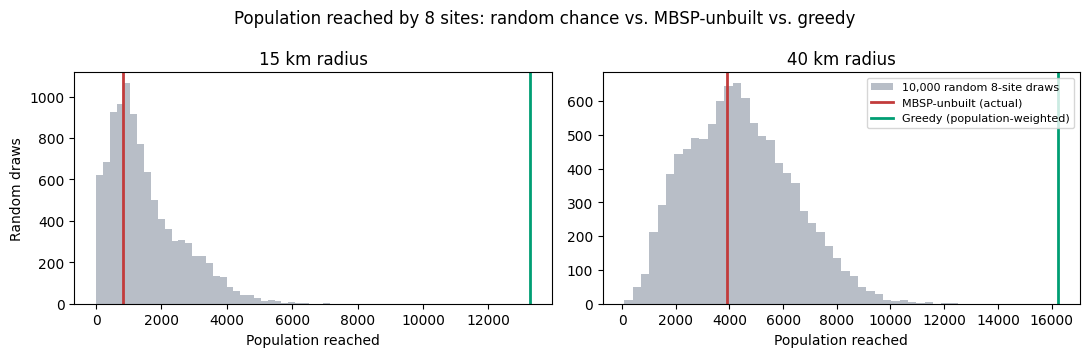

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=False)
for ax, radius, null_dist, mbsp_val, greedy_val in [
    (axes[0], 15, null_15, mbsp_reach_15, greedy_reach_15),
    (axes[1], 40, null_40, mbsp_reach_40, greedy_reach_40),
]:
    ax.hist(null_dist, bins=40, color="#B8BEC7", label="10,000 random 8-site draws")
    ax.axvline(mbsp_val, color="#C23B3B", lw=2, label="MBSP-unbuilt (actual)")
    ax.axvline(greedy_val, color="#009E73", lw=2, label="Greedy (population-weighted)")
    ax.set_title(f"{radius} km radius")
    ax.set_xlabel("Population reached")
axes[0].set_ylabel("Random draws")
axes[1].legend(fontsize=8, loc="upper right")
fig.suptitle("Population reached by 8 sites: random chance vs. MBSP-unbuilt vs. greedy")
fig.tight_layout()
plt.show()

### Sensitivity: drop SA1s that also contain a well-covered village

In an SA1 that also holds a `redundant` village, part of its Census population may already have two
networks, so crediting the whole SA1 as unserved demand could overstate it. Re-run both tests on the
SA1s where **every** village is fragile. (Still no splitting: an SA1 is either fully in or fully out.)


In [10]:
mixed_sa1 = set(vg.loc[vg["resilience_tier"] == "redundant", "sa1_code"])
keep = ~sa1_demand["sa1_code"].isin(mixed_sa1).to_numpy()
print(f"SA1s dropped: {int((~keep).sum())} of {len(sa1_demand)}  "
      f"(population {sa1_pop[~keep].sum():,.0f} of {total_pop:,.0f}, {sa1_pop[~keep].sum()/total_pop:.0%})")

sens = {}
for radius in (40, 15):
    reach = (hav(sa1_lat, sa1_lon, cand_lat, cand_lon) <= radius)[keep]
    pop_k = sa1_pop[keep]
    mbsp_k = float(pop_k[(hav(sa1_lat, sa1_lon, unbuilt["latitude"].to_numpy(),
                              unbuilt["longitude"].to_numpy()) <= radius)[keep].any(axis=1)].sum())
    covered_k = np.zeros(len(pop_k), dtype=bool)
    for _ in range(k):                                  # greedy, same algorithm as above
        gain = ((reach & ~covered_k[:, None]) * pop_k[:, None]).sum(axis=0)
        covered_k |= reach[:, int(gain.argmax())]
    greedy_k = float(pop_k[covered_k].sum())
    rng_s = np.random.default_rng(42)
    null_k = np.array([pop_k[reach[:, rng_s.choice(n_cand, size=k, replace=False)].any(axis=1)].sum()
                       for _ in range(N_TRIALS)])
    sens[radius] = (mc_p(null_k, mbsp_k), mc_p(null_k, greedy_k))
    print(f"{radius} km: MBSP reach {mbsp_k:,.0f} (Test A p={sens[radius][0]:.4f}) | "
          f"greedy reach {greedy_k:,.0f} (Test B p={sens[radius][1]:.4f})")


SA1s dropped: 13 of 125  (population 3,011 of 36,973, 8%)
40 km: MBSP reach 3,533 (Test A p=0.6038) | greedy reach 15,848 (Test B p=0.0001)


15 km: MBSP reach 441 (Test A p=0.8383) | greedy reach 13,269 (Test B p=0.0001)


## Conclusion

In [11]:
def verdict(p_mbsp, p_greedy):
    return p_mbsp >= 0.05 and p_greedy < 0.05

print("H2 SUMMARY")
print("=" * 60)
print(f"At 40 km: MBSP-unbuilt reaches {mbsp_reach_40/total_pop:.1%} of demand population;")
print(f"  Test A p={p40[0]:.4f} -> no evidence it reaches more people than a random 8-site choice.")
print(f"  Greedy reaches {greedy_reach_40/total_pop:.1%}; Test B p={p40[1]:.4f} -> clearly better than chance.")
print(f"At 15 km: Test A p={p15[0]:.4f}, Test B p={p15[1]:.4f} -- same pattern, stricter radius.")
print(f"Sensitivity (all-fragile SA1s only): 40 km A={sens[40][0]:.4f} B={sens[40][1]:.4f}; "
      f"15 km A={sens[15][0]:.4f} B={sens[15][1]:.4f}")
print()
supported = all(verdict(*p) for p in (p40, p15, sens[40], sens[15]))
print("=> H2 is SUPPORTED" if supported else "=> H2 is NOT clearly supported")
print("   The unbuilt-MBSP backlog is statistically indistinguishable from a RANDOM choice of 8 sites")
print("   (no detectable population targeting), while a simple population-weighted greedy method")
print("   is significantly better than chance on the same candidate pool. This is absence of evidence")
print("   of targeting, not proof that MBSP did worse than chance.")


H2 SUMMARY
At 40 km: MBSP-unbuilt reaches 10.6% of demand population;
  Test A p=0.5735 -> no evidence it reaches more people than a random 8-site choice.
  Greedy reaches 44.0%; Test B p=0.0001 -> clearly better than chance.
At 15 km: Test A p=0.6827, Test B p=0.0001 -- same pattern, stricter radius.
Sensitivity (all-fragile SA1s only): 40 km A=0.6038 B=0.0001; 15 km A=0.8383 B=0.0001

=> H2 is SUPPORTED
   The unbuilt-MBSP backlog is statistically indistinguishable from a RANDOM choice of 8 sites
   (no detectable population targeting), while a simple population-weighted greedy method
   is significantly better than chance on the same candidate pool. This is absence of evidence
   of targeting, not proof that MBSP did worse than chance.


**Caveat, stated plainly.** This is not evidence that MBSP site selection was wrong — land
tenure, engineering feasibility, backhaul availability, staged funding rounds, and (most
importantly) community consultation are real constraints this population-only model cannot
see. It is evidence that a reproducible, population-weighted method surfaces materially
different priorities than the current backlog, and is worth using as one input into future
funding rounds — exactly what `app/app.py`'s Recommendations tab lets a planner explore
interactively, with this same algorithm.